In [1]:
from google.colab import files
uploaded = files.upload()

Saving student_followup_prioritisation_final.csv to student_followup_prioritisation_final.csv


In [21]:
import pandas as pd

df=pd.read_csv('student_followup_prioritisation_final.csv')

df

,Student_ID,Program,Student_Status,Outstanding_Action,Academic_Event,Days_Until_Commencement,Contact_Count,Follow_Up_Completed,Follow_Up_Priority,Progression_Outcome
0,S00001,Occupational Therapy,Offer Holder,Offer Acceptance Required,Psychology Admissions,27,0,Yes,Medium,Progressed
1,S00002,Physiotherapy,Accepted Not Enrolled,Enrolment Completion Required,Psychology Admissions,19,4,Yes,Medium,Progressed
2,S00003,Physiotherapy,Applicant,Application Submission Required,Nursing Offer Round,85,2,Yes,Low,Stalled
3,S00004,Nursing,Accepted Not Enrolled,Enrolment Completion Required,T3 Enrolment,12,3,Yes,Medium,Progressed
4,S00005,Education,Applicant,Application Submission Required,T2 Enrolment,70,0,Yes,Low,Progressed
...,...,...,...,...,...,...,...,...,...,...
9995,S09996,Nursing,Accepted Not Enrolled,Enrolment Completion Required,T1 Enrolment,15,1,Yes,Medium,Progressed
9996,S09997,Occupational Therapy,Accepted Not Enrolled,Enrolment Completion Required,T1 Enrolment,17,0,No,Medium,Progressed
9997,S09998,Clinical Psychology,Accepted Not Enrolled,Enrolment Completion Required,T1 Enrolment,29,2,Yes,Medium,Progressed
9998,S09999,Nursing,Accepted Not Enrolled,Enrolment Completion Required,T1 Enrolment,20,2,Yes,Medium,Progressed


In [4]:
df.columns

Index(['Student_ID', 'Program', 'Student_Status', 'Outstanding_Action',
       'Academic_Event', 'Days_Until_Commencement', 'Contact_Count',
       'Follow_Up_Completed', 'Follow_Up_Priority', 'Progression_Outcome'],
      dtype='object')

In [22]:
df['Progression_Outcome'].value_counts()

,count
Progression_Outcome,
Progressed,6345
Stalled,3655


In [23]:
df['Progression_Outcome'] = df['Progression_Outcome'].map({
    'Progressed': 1,
    'Stalled': 0
})

df['Progression_Outcome'].head()

,Progression_Outcome
0,1
1,1
2,0
3,1
4,1


In [24]:
features = [
    'Program',
    'Student_Status',
    'Outstanding_Action',
    'Academic_Event',
    'Days_Until_Commencement',
    'Contact_Count',
    'Follow_Up_Priority'
]

X = df[features]
y = df['Progression_Outcome']

print(X.head())

                Program         Student_Status  \
0  Occupational Therapy           Offer Holder   
1         Physiotherapy  Accepted Not Enrolled   
2         Physiotherapy              Applicant   
3               Nursing  Accepted Not Enrolled   
4             Education              Applicant   

                Outstanding_Action         Academic_Event  \
0        Offer Acceptance Required  Psychology Admissions   
1    Enrolment Completion Required  Psychology Admissions   
2  Application Submission Required    Nursing Offer Round   
3    Enrolment Completion Required           T3 Enrolment   
4  Application Submission Required           T2 Enrolment   

   Days_Until_Commencement  Contact_Count Follow_Up_Priority  
0                       27              0             Medium  
1                       19              4             Medium  
2                       85              2                Low  
3                       12              3             Medium  
4                

In [25]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

X.head()

/tmp/ipykernel_2340/2337345717.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_2340/2337345717.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_2340/2337345717.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guid

,Program,Student_Status,Outstanding_Action,Academic_Event,Days_Until_Commencement,Contact_Count,Follow_Up_Priority
0,6,2,3,2,27,0,2
1,7,0,2,2,19,4,2
2,7,1,1,1,85,2,1
3,5,0,2,5,12,3,2
4,2,1,1,4,70,0,1


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 7)
(2000, 7)


In [27]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [28]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 67.70%


In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.73      0.22      0.34       751
           1       0.67      0.95      0.79      1249

    accuracy                           0.68      2000
   macro avg       0.70      0.59      0.56      2000
weighted avg       0.69      0.68      0.62      2000



In [30]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
6,Follow_Up_Priority,0.388875
2,Outstanding_Action,0.355980
5,Contact_Count,0.106012
4,Days_Until_Commencement,0.082735
0,Program,0.027217
3,Academic_Event,0.020330
1,Student_Status,0.018851


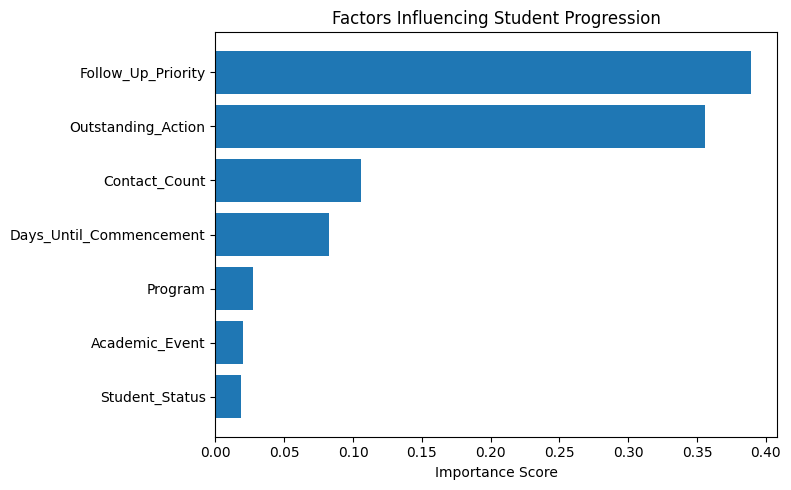

In [31]:
import matplotlib.pyplot as plt

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(8,5))
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title("Factors Influencing Student Progression")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()